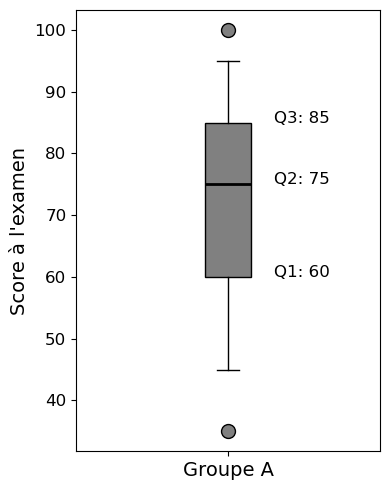

In [6]:
import matplotlib.pyplot as plt

# Données statistiques manuelles
box_data = {
    'med': 75,      # Médiane (Q2)
    'q1': 60,       # 1er quartile
    'q3': 85,       # 3e quartile
    'whislo': 45,   # Valeur minimale (hors outliers)
    'whishi': 95,   # Valeur maximale (hors outliers)
    'fliers': [35, 100]  # Outliers
}

fig, ax = plt.subplots(figsize=(4, 5))

# Création du boxplot à partir des stats
ax.bxp([box_data], showfliers=True, patch_artist=True,
       boxprops=dict(facecolor='gray'),
       flierprops=dict(marker='o', markerfacecolor='gray', markersize=10),
       medianprops=dict(color='black', linewidth=2))

# Mise en forme
ax.set_ylabel("Score à l'examen",fontsize=14)
ax.tick_params(axis='y', labelsize=12)
ax.set_xticks([1])
ax.set_xticklabels(["Groupe A"],fontsize=14)
# ax.set_title("Diagramme en boîte des scores d'examen")

# Annoter les quartiles
ax.annotate("Q1: 60", xy=(1, 60), xytext=(1.15, 60), textcoords='data', color='black',fontsize=12)
ax.annotate("Q2: 75", xy=(1, 75), xytext=(1.15, 75), textcoords='data', color='black',fontsize=12)
ax.annotate("Q3: 85", xy=(1, 85), xytext=(1.15, 85), textcoords='data', color='black',fontsize=12)

plt.tight_layout()
plt.savefig("boxplot_scores_examens.png", dpi=300)
plt.show()


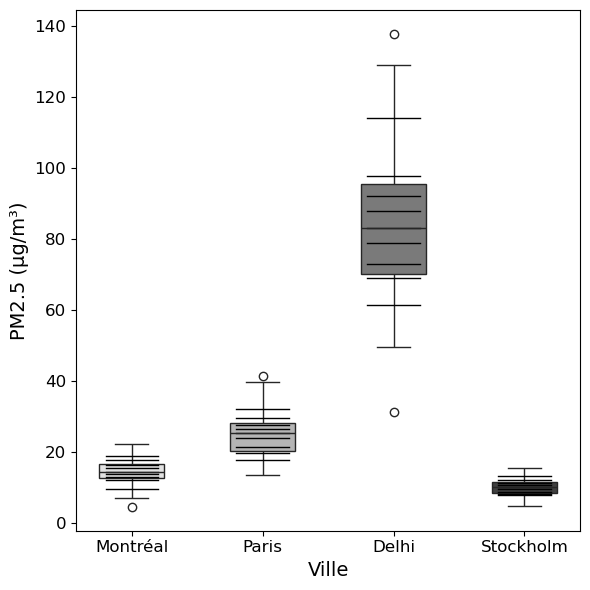

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Simuler les données PM2.5 pour 4 villes
np.random.seed(42)
villes = ['Montréal', 'Paris', 'Delhi', 'Stockholm']
data = []

for ville in villes:
    if ville == 'Delhi':
        pollution = np.concatenate([np.random.normal(80, 15, 90), np.random.normal(120, 10, 10)])
    elif ville == 'Paris':
        pollution = np.random.normal(25, 6, 100)
    elif ville == 'Montréal':
        pollution = np.random.normal(15, 4, 100)
    else:
        pollution = np.random.normal(10, 2.5, 100)
    
    for val in pollution:
        data.append({'Ville': ville, 'PM2.5': val})

df = pd.DataFrame(data)

# Graphique avec boxplot étendu
plt.figure(figsize=(6, 6))
# sns.boxplot(data=df, x='Ville', y='PM2.5', width=0.5, palette='pastel'   )
sns.boxplot(
    data=df,
    x='Ville',
    y='PM2.5',
    hue='Ville',
    width=0.5,
    palette='Greys',
    legend=False
)
# Ajouter les déciles manuellement
# Ajouter les déciles
for i, ville in enumerate(villes):
    d = df[df['Ville'] == ville]['PM2.5']
    deciles = np.percentile(d, np.arange(10, 100, 10))

    for dec in deciles:
        plt.plot(
            [i - 0.2, i + 0.2],  # largeur de la ligne
            [dec, dec],
            color='black',
            linewidth=1
        )
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Ville", fontsize=14)
plt.ylabel("PM2.5 (µg/m³)", fontsize=14)
plt.tight_layout()
plt.savefig("boxplot_environnemet.png", dpi=300)
plt.show()

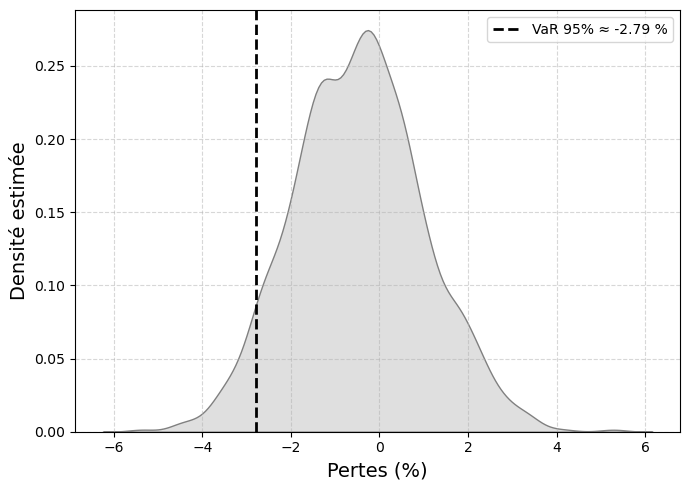

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Simuler des pertes financières quotidiennes (%)
np.random.seed(42)
pertes = np.random.normal(loc=-0.5, scale=1.5, size=1000)  # pertes moyennes négatives

# Calcul du 95e percentile (Value at Risk)
var_95 = np.percentile(pertes, 5)  # On prend le 5e percentile car c'est dans la queue gauche

# Tracé KDE
plt.figure(figsize=(7, 5))
sns.kdeplot(pertes, fill=True, color='gray', bw_adjust=0.8)

# Ligne verticale au 5e percentile (VaR à 95 %)
plt.axvline(var_95, color='black', linestyle='--', linewidth=2,
            label=f"VaR 95% ≈ {var_95:.2f} %")

# Mise en forme
# plt.title("Distribution des pertes financières quotidiennes")
plt.xlabel("Pertes (%)",fontsize=14)
plt.ylabel("Densité estimée",fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Sauvegarde et affichage
plt.tight_layout()
plt.savefig("var95_pertes_financieres.png", dpi=300)
plt.show()


## Pratique guidée : Calcul des percentiles

In [4]:
import numpy as np

# Données triées (25 étudiants)
notes = np.array([
    28, 32, 35, 40, 42, 45, 48, 50, 52, 55,
    57, 60, 62, 65, 68, 70, 72, 75, 78, 82,
    85, 88, 90, 94, 100
])

# Méthode 'weibull' (R-6) : correspond à la formule pédagogique (n+1)*p/100
p25 = np.percentile(notes, 25, method='weibull')
p50 = np.percentile(notes, 50, method='weibull')
p75 = np.percentile(notes, 75, method='weibull')

print("Percentiles corrects :")
print(f"P₂₅ (Q1) = {p25:.1f}")
print(f"P₅₀ (médiane) = {p50:.1f}  ← 13ᵉ valeur dans la liste triée")
print(f"P₇₅ (Q3) = {p75:.1f}")

# Vérification manuelle de la médiane
print(f"\n Vérification médiane :")
print(f"   Nombre d'observations : n = {len(notes)}")
print(f"   Position médiane : (25 + 1) / 2 = 13")
print(f"   13ᵉ valeur = notes[12] = {notes[12]}")  # Index 0-based : 12 = 13ᵉ position

Percentiles corrects :
P₂₅ (Q1) = 46.5
P₅₀ (médiane) = 62.0  ← 13ᵉ valeur dans la liste triée
P₇₅ (Q3) = 80.0

 Vérification médiane :
   Nombre d'observations : n = 25
   Position médiane : (25 + 1) / 2 = 13
   13ᵉ valeur = notes[12] = 62
